<a href="https://colab.research.google.com/github/vblancoOR/econometria/blob/main/Multicolinealidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import pandas as pd #librería para manejo de datos

datos= pd.read_csv("https://rtgodwin.com/data/houseprice.csv") #Lee base de datos de web...

In [2]:
import statsmodels.api as sm

y=datos["Price"]
X=datos[['Lot.Size', 'Age', 'Land.Value',   'Living.Area', 'Bedrooms']]

mco = sm.OLS(y, sm.add_constant(X)).fit()
print(mco.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.614
Model:                            OLS   Adj. R-squared:                  0.612
Method:                 Least Squares   F-statistic:                     546.8
Date:                Mon, 11 Nov 2024   Prob (F-statistic):               0.00
Time:                        13:25:22   Log-Likelihood:                -21497.
No. Observations:                1728   AIC:                         4.301e+04
Df Residuals:                    1722   BIC:                         4.304e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        4.108e+04   6092.721      6.742      

# Número de Condición

In [4]:
import numpy as np

CN = np.sqrt(mco.condition_number) #Número de Condición
print(CN)

457.7137917413814


# Factor de Inflación de la Varianza

In [5]:
import statsmodels.stats.outliers_influence as oi

vifs=[oi.variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vifs

[1.5504263431767245,
 1.9458880503995022,
 2.4516287948461417,
 20.032370077525368,
 19.547148888313494]

# Matriz de Correlaciones

In [6]:
corr_matrix=np.corrcoef(X.T)
print(corr_matrix)

[[ 1.         -0.01635219  0.05922184  0.16344987  0.11398209]
 [-0.01635219  1.         -0.0218179  -0.17424195  0.0271248 ]
 [ 0.05922184 -0.0218179   1.          0.42344081  0.20244922]
 [ 0.16344987 -0.17424195  0.42344081  1.          0.65619568]
 [ 0.11398209  0.0271248   0.20244922  0.65619568  1.        ]]


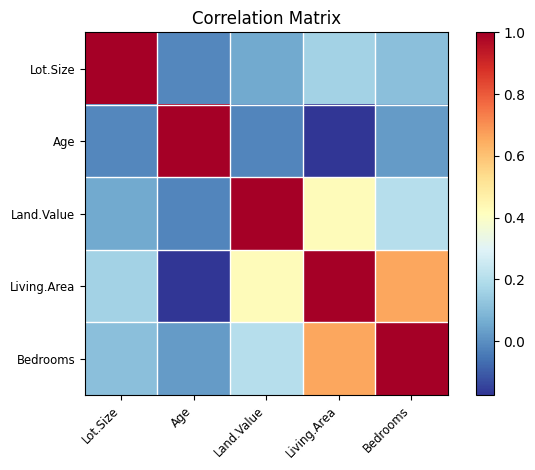

In [9]:
import statsmodels.graphics.api as smg
import matplotlib.pylab as plt
smg.plot_corr(corr_matrix, xnames=['Lot.Size', 'Age', 'Land.Value',   'Living.Area', 'Bedrooms'])
plt.show()